<h1>¿Cómo debo fijar el precio del seguro de auto en los Estados Unidos?</h1>

<h2>Introducción</h2>

<p><strong>Contexto del Negocio.</strong> La capacidad de fijar el precio de una cotización de seguro correctamente tiene un impacto significativo en las decisiones de gestión y los estados financieros de las aseguradoras. Usted es el científico de datos en jefe de una nueva compañía de seguros que se enfoca en brindar seguros asequibles a los millennials. Tiene la tarea de evaluar el estado actual de las compañías de seguros para ver qué factores cobran primas los grandes proveedores de seguros. Afortunadamente para usted, su empresa ha compilado un conjunto de datos encuestando lo que la gente paga actualmente por los seguros de las grandes empresas. Sus hallazgos se utilizarán como base para desarrollar la oferta de seguros de automóviles millenial de su empresa. </p>
<p><strong>Problema de Negocio.</strong> Su tarea es construir un modelo <strong>mínimo</strong> para predecir el costo del seguro a partir del conjunto de datos usando varias características de un asegurado.</p>
<p><strong>Contexto Analítico.</strong> Los datos residen en un archivo CSV que se ha limpiado previamente para usted y se puede leer directamente. A lo largo del caso, estará iterando en su modelo inicial muchas veces en función de las dificultades comunes que surgen y que discutimos en casos anteriores. Utilizará el paquete <code>statsmodels</code> de Python para crear y analizar estos modelos lineales.</p>

In [1]:
### Load relevant packages

import pandas                  as pd
import numpy                   as np
import matplotlib.pyplot       as plt
import seaborn                 as sns
from multiple_linear_regression import MultipleLinearRegression
import os
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets

# This statement allow to display plot without asking to 
%matplotlib inline

# always make it pretty 
plt.style.use('ggplot')

ModuleNotFoundError: No module named 'pandas'

<h2>Explorando los datos</h2>

En primer lugar, cargamos la información disponible para el análisis de la información.

<p>Las siguientes son las columnas en el conjunto de datos.:</p>
<ol>
<li><strong>state</strong>: Estado donde ocurrió el punto de compra</li>
<li><strong>group_size</strong>: ¿Cuántas personas estarán cubiertas por la póliza? (1, 2, 3 o 4) </li>
<li><strong>homeowner</strong>: Si el cliente posee una casa (0=no, 1=si)</li>
<li><strong>car_age</strong>: Antigüedad del carro del cliente (Cuántos años tiene el carro)</li>
<li><strong>car_value</strong>: Valor del coche cuando era nuevo</li>
<li><strong>risk_factor</strong>: Una evaluación ordinal de cuán arriesgado es el cliente (0,1, 2, 3, 4) </li>
<li><strong>age_oldest</strong>: Edad de la persona de mayor edad en el grupo del cliente</li>
<li><strong>age_youngest</strong>: Edad de la persona más joven en el grupo del cliente</li>
<li><strong>married_couple</strong>: ¿El grupo de clientes contiene una pareja casada? (0=no, 1=si) </li>
<li><strong>C_previous</strong>: Lo que el cliente tenía anteriormente o tiene actualmente para la opción de producto C (0=ninguna, 1, 2, 3,4)</li>
<li><strong>duration_previous</strong>: Cuánto tiempo (en años) el cliente estuvo cubierto por su emisor anterior</li>
<li><strong>A,B,C,D,E,F,G</strong>: Las opciones de cobertura:</li>
<li><strong>A</strong>: Colisión (niveles: 0, 1, 2);</li>
<li><strong>B</strong>: Remolque (levels: 0, 1);</li>
<li><strong>C</strong>: Daños corporales (niveles: 1, 2, 3, 4);</li>
<li><strong>D</strong>: Daño a la propiedad (niveles 1, 2, 3);</li>
<li><strong>E</strong>: Reembolso de alquiler (niveles: 0, 1);</li>
<li><strong>F</strong>: Exhaustiva (niveles: 0, 1, 2, 3);</li>
<li><strong>G</strong>: Protección Médica/Lesiones Personales (niveles: 1, 2, 3, 4)</li>
<li><strong>cost</strong>: costo de las opciones de cobertura cotizadas </li>
</ol>

In [2]:
Datos = pd.read_csv('Allstate-cost-cleaned.csv',
    dtype = { # indicate categorical variables
        'A': 'category',
        'B': 'category',
        'C': 'category',
        'D': 'category',
        'E': 'category',
        'F': 'category',
        'G': 'category',
        'car_value': 'category',
        'state': 'category',
        'married_couple':'category'
    }
)

In [3]:
Datos.head()

,Unnamed: 0,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,0,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,0,0,1,1,0,0,4,543
1,1,OK,1,0,9,f,0.0,24,24,0,3.0,9.0,2,1,1,3,1,3,2,611
2,2,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,691
3,3,PA,1,1,7,f,0.0,74,74,0,2.0,15.0,2,0,2,3,1,2,2,695
4,4,AR,1,0,4,d,4.0,26,26,0,3.0,1.0,1,0,1,1,0,2,2,628


Es necesario realizar una transformación de un par de columnas para el correcto manejo posterior de la información.

In [4]:
Datos = Datos.drop(columns=['Unnamed: 0'])

In [5]:
Datos['C_previous']=Datos['C_previous'].astype('int64')
Datos['risk_factor']=Datos['risk_factor'].astype('int64')

In [6]:
Datos.shape

(15483, 19)

In [7]:
Datos.head(10)

,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
0,OK,1,0,9,f,0,24,24,0,3,9.0,0,0,1,1,0,0,4,543
1,OK,1,0,9,f,0,24,24,0,3,9.0,2,1,1,3,1,3,2,611
2,PA,1,1,7,f,0,74,74,0,2,15.0,2,0,2,3,1,2,2,691
3,PA,1,1,7,f,0,74,74,0,2,15.0,2,0,2,3,1,2,2,695
4,AR,1,0,4,d,4,26,26,0,3,1.0,1,0,1,1,0,2,2,628
5,AR,1,0,4,d,4,26,26,0,3,1.0,1,0,2,1,0,2,2,625
6,AR,1,0,4,d,4,26,26,0,3,1.0,1,0,2,1,0,2,2,628
7,OK,1,0,13,f,3,22,22,0,0,0.0,0,0,1,1,0,0,2,596
8,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,711
9,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,722


In [8]:
Datos.loc[7:11]

,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
7,OK,1,0,13,f,3,22,22,0,0,0.0,0,0,1,1,0,0,2,596
8,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,711
9,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,722
10,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,722
11,OK,1,0,13,f,3,22,22,0,1,3.0,2,0,1,1,0,3,2,673


In [9]:
Datos.iloc[7:11]

,state,group_size,homeowner,car_age,car_value,risk_factor,age_oldest,age_youngest,married_couple,C_previous,duration_previous,A,B,C,D,E,F,G,cost
7,OK,1,0,13,f,3,22,22,0,0,0.0,0,0,1,1,0,0,2,596
8,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,711
9,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,722
10,OK,1,0,13,f,3,22,22,0,0,0.0,2,0,1,1,0,3,2,722


In [11]:
Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15483 entries, 0 to 15482
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   state              15483 non-null  category
 1   group_size         15483 non-null  int64   
 2   homeowner          15483 non-null  int64   
 3   car_age            15483 non-null  int64   
 4   car_value          15435 non-null  category
 5   risk_factor        15483 non-null  int64   
 6   age_oldest         15483 non-null  int64   
 7   age_youngest       15483 non-null  int64   
 8   married_couple     15483 non-null  category
 9   C_previous         15483 non-null  int64   
 10  duration_previous  15483 non-null  float64 
 11  A                  15483 non-null  category
 12  B                  15483 non-null  category
 13  C                  15483 non-null  category
 14  D                  15483 non-null  category
 15  E                  15483 non-null  category
 16  F   

In [12]:
Datos['cost'].describe()

count    15483.000000
mean       633.947878
std         47.336855
min        354.000000
25%        602.000000
50%        633.000000
75%        664.000000
max        842.000000
Name: cost, dtype: float64

¿Cómo varía el costo promedio de la póliza según el nivel de cobertura por daños corporales (opción C) seleccionado por los clientes?

In [13]:
Datos[['C','cost']].groupby(['C']).mean().reset_index()

C:\Users\legion\AppData\Local\Temp\ipykernel_28376\3048440440.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Datos[['C','cost']].groupby(['C']).mean().reset_index()


,C,cost
0,1,634.172544
1,2,633.882897
2,3,634.327139
3,4,631.157494


Aunque se esperaría que a mayor nivel de cobertura por daños corporales (opción C) el costo de la póliza aumente, los datos muestran que el costo promedio es relativamente similar entre los niveles 1 a 3, y curiosamente es más bajo en el nivel 4. Esto sugiere que el nivel de cobertura no está fuertemente asociado al costo final, o que podrían estar influyendo otros factores en el precio de la póliza.

Ahora, ¿qué tanta variabilidad existe en el costo de la póliza para cada nivel de cobertura por daños corporales (opción C)?

In [15]:
Datos[['C','cost']].groupby(['C']).std().reset_index()

C:\Users\legion\AppData\Local\Temp\ipykernel_28376\566558839.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Datos[['C','cost']].groupby(['C']).std().reset_index()


,C,cost
0,1,51.745039
1,2,44.545519
2,3,45.985313
3,4,42.895880


El costo de la póliza presenta una mayor variabilidad para el nivel de cobertura 1 (desviación estándar ≈ 51.75), lo cual indica que los clientes que eligen este nivel pueden estar recibiendo pólizas con un rango más amplio de precios. A medida que aumenta el nivel de cobertura (hasta el nivel 4), la variabilidad del costo disminuye, lo que sugiere que las pólizas más completas tienen precios más estandarizados.

Ahora, nos surge una nueva pregunta:

¿Cómo interactúan los niveles de cobertura por colisión (A) y por daños corporales (C) en el costo promedio de la póliza, y qué implicaciones puede tener esto en la interpretación marginal del efecto de una sola cobertura?

In [16]:
pd.pivot_table(
    Datos,
    index='C',
    columns='A',
    values='cost',
    aggfunc='mean'
)

C:\Users\legion\AppData\Local\Temp\ipykernel_28376\2108797613.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


A,0,1,2
C,,,
1,602.224906,653.065246,660.334877
2,604.126536,644.506934,643.364611
3,602.838471,637.731672,646.545455
4,592.985507,635.839633,638.100000


Cuando se analiza solo la variable `C`, parece que el costo promedio disminuye al aumentar el nivel de cobertura por daños corporales. Sin embargo, al desagregar por niveles de `A` (colisión), se observa que dentro de cada nivel de `A` el costo promedio también disminuye con `C`, pero con diferentes tasas. Esta variación sugiere que la cobertura por colisión puede estar actuando como una variable de confusión: modifica el efecto observado de `C` sobre el costo. Este patrón es una manifestación típica de la **paradoja de Simpson**, donde la tendencia global puede ocultar o invertir relaciones existentes a nivel subgrupo.

Ahora, creamos una pequeña función que permite realizar diagramas de violín entre una variable categórica y nuestra variable de respuesta, con el fin de encontrar algunos patrones adicionales que pueden ser útiles a la hora de decidir si algunas de estas variables pueden aportar de manera significativa a explicar la variabilidad en los costos de los seguros.

In [17]:
def violingraphs(var):
    #var es la variable sobre la que quiero segmentar el gráfico de violín
    
    sns.violinplot(hue=var,y='cost',data=Datos)

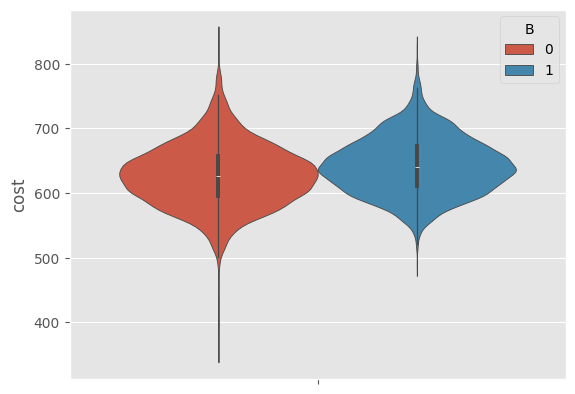

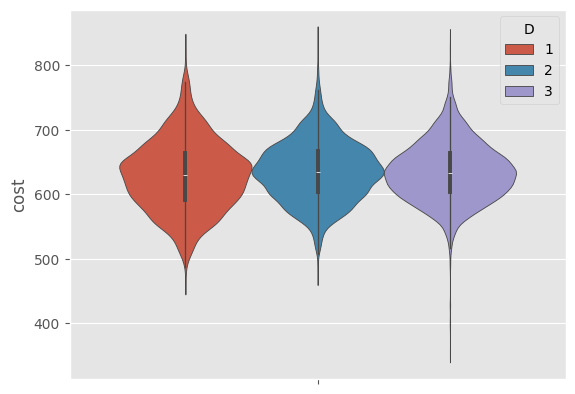

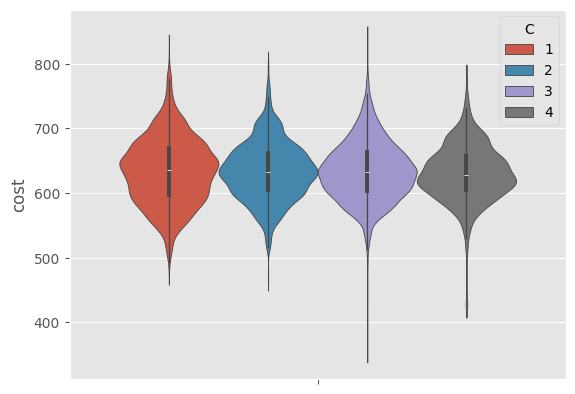

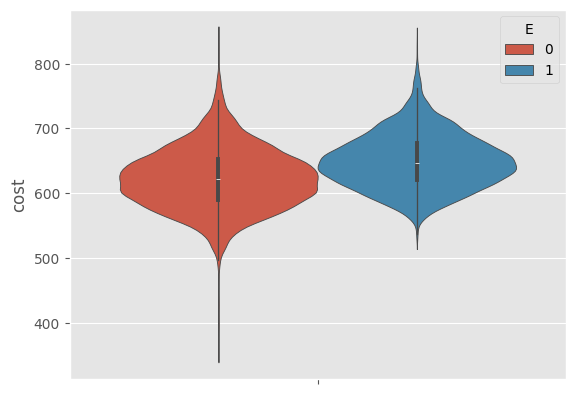

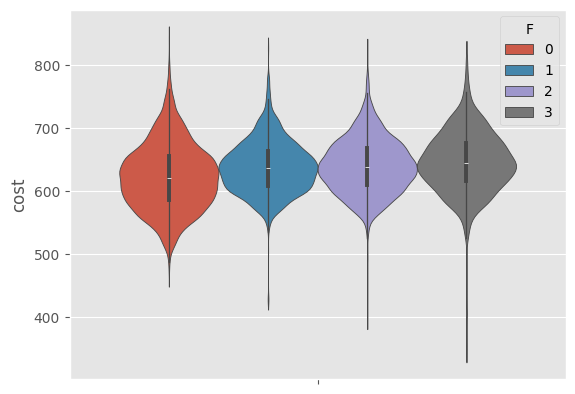

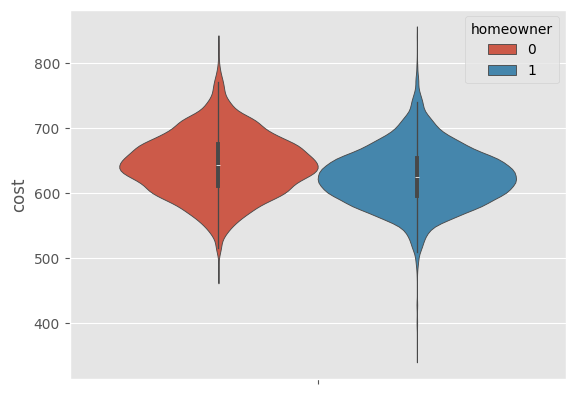

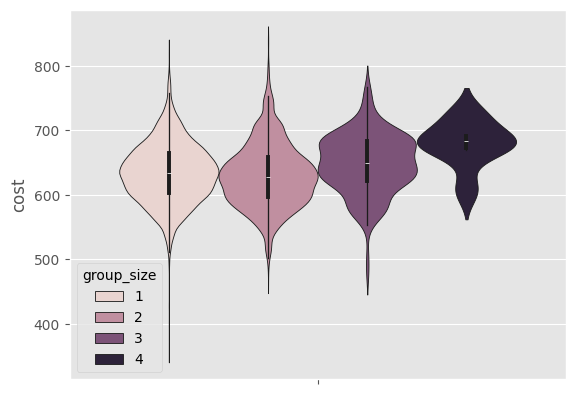

In [18]:
set_variable = ipywidgets.Dropdown(
    options = ['A','B','C','D','E','F','G','homeowner','group_size'],
    description = "Variable:",
    disable = False
)

interactive(children=(Dropdown(description='Variable:', options=('A', 'B', 'C', 'D', 'E', 'F', 'G', 'homeowner…

<function __main__.violingraphs(var)>

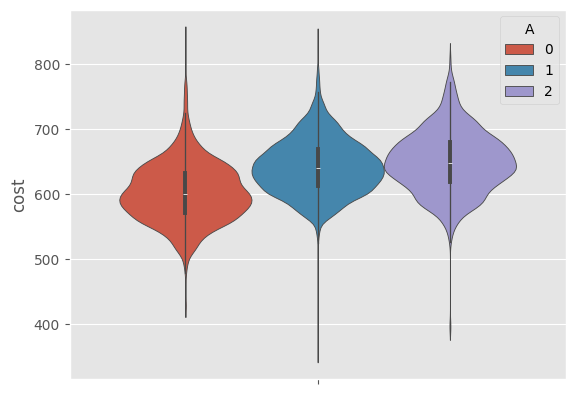

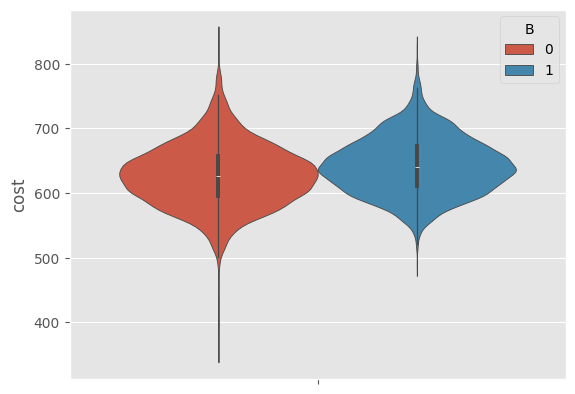

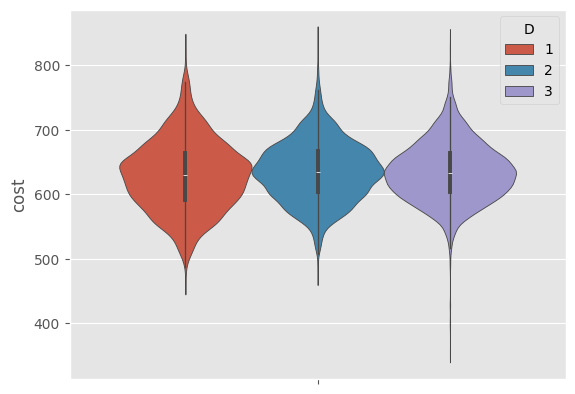

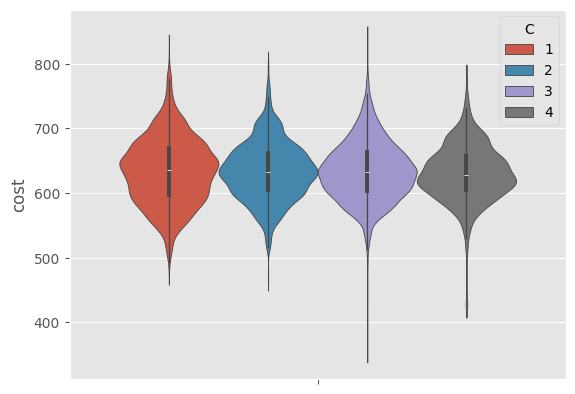

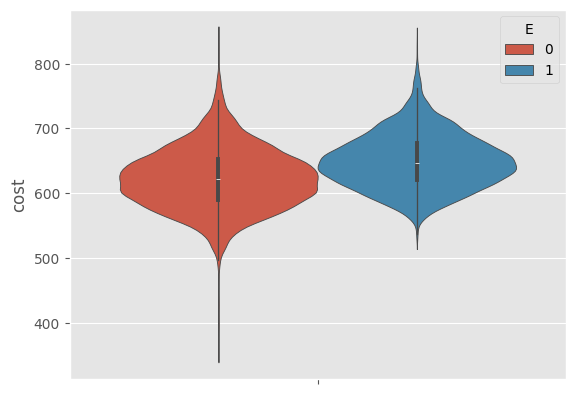

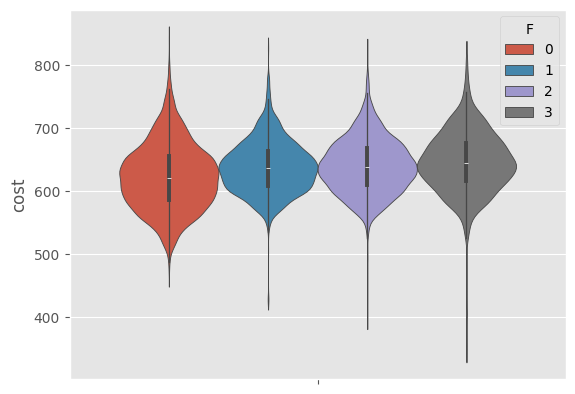

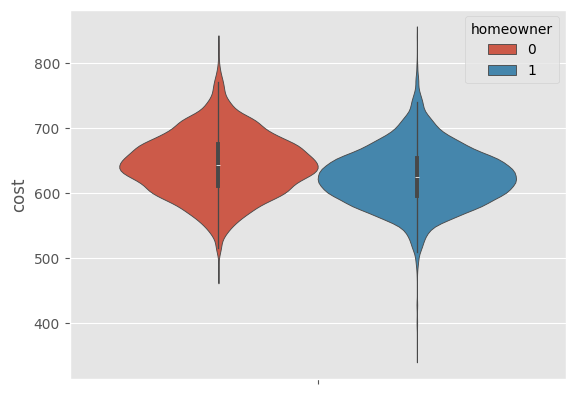

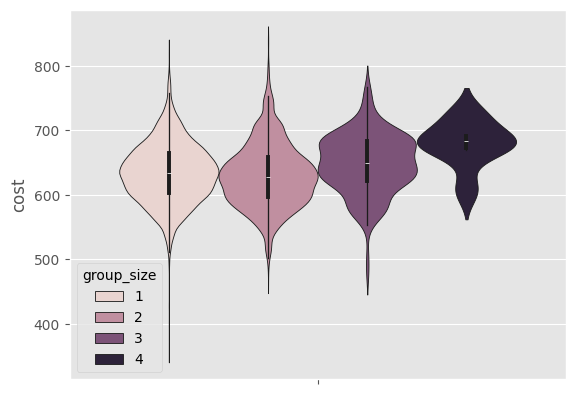

In [19]:
ipywidgets.interact(violingraphs, var=set_variable)

| Variable       | ¿Incluir en el modelo? | Justificación                                                                 |
|----------------|------------------------|--------------------------------------------------------------------------------|
| `group_size`   | ✅ Sí                  | Asociado a economía de escala y menor variabilidad en el costo                |
| `homeowner`    | ✅ Sí                  | Proxy de estabilidad financiera o menor riesgo                                |
| `F`            | ✅ Sí                  | Coberturas más altas se asocian con mayor costo                               |
| `E`            | ✅ Sí                  | Claramente incrementa el costo promedio de la póliza                          |
| `C`            | ✅ Sí (con cautela)    | Patrón inverso al esperado; revisar interacciones (posible paradoja de Simpson)|
| `D`            | 🟨 Tal vez             | Diferencias leves entre niveles, impacto limitado                             |
| `B`            | 🟨 Tal vez             | Ligeramente más costoso, pero efecto marginal                                  |
| `A`            | ✅ Sí                  | Relación clara y directa con el incremento del costo                          |

¿Cómo influye la antigüedad del vehículo (`car_age`) en el costo de la póliza (`cost`)? ¿Existe una relación lineal o no lineal entre ambas variables?

<Axes: xlabel='car_age', ylabel='cost'>

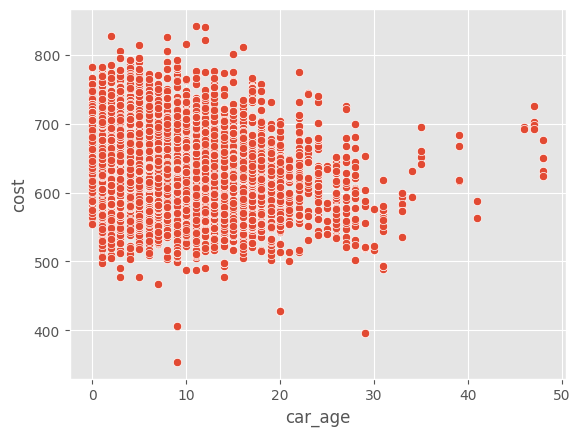

In [20]:
sns.scatterplot(data=Datos,x='car_age',y='cost')

El gráfico sugiere una leve tendencia decreciente: a medida que el vehículo es más antiguo, el costo promedio tiende a disminuir. Sin embargo, la relación no parece estrictamente lineal, y se observa una mayor dispersión para autos más viejos, especialmente después de los 20 años. Esto podría indicar que la variable `car_age` tiene un efecto no lineal o que intervienen otros factores como el valor original del vehículo o el tipo de cobertura elegida.

<Axes: xlabel='car_age', ylabel='cost'>

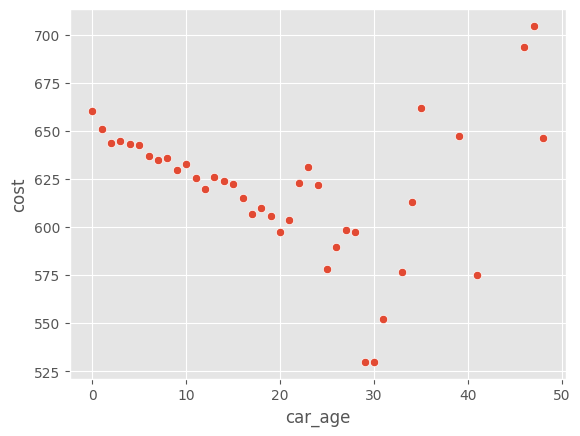

In [21]:
D1=Datos[['car_age','cost']].groupby(['car_age']).mean().reset_index()
sns.scatterplot(data=D1,x='car_age',y='cost')

Al promediar el costo por cada edad del vehículo, se observa una tendencia general decreciente: a mayor antigüedad del carro, menor es el costo promedio de la póliza. Sin embargo, a partir de los 30 años, esta relación deja de ser estable y aparecen valores atípicos con incrementos inesperados en el costo. Esto puede deberse a baja frecuencia de observaciones en esas edades extremas o a características particulares de vehículos muy antiguos (e.g., autos clásicos o de colección).

In [ ]:
sns.scatterplot(data=Datos,x='car_age',y='cost',hue=Datos['C'].tolist())

In [ ]:
sns.scatterplot(data=Datos,x='car_age',y='cost',hue=Datos['B'].tolist())

In [ ]:
D3=Datos[['car_age','cost','B']].groupby(['car_age','B']).mean().reset_index()
sns.scatterplot(data=D3,x='car_age',y='cost',hue=D3['B'].tolist())

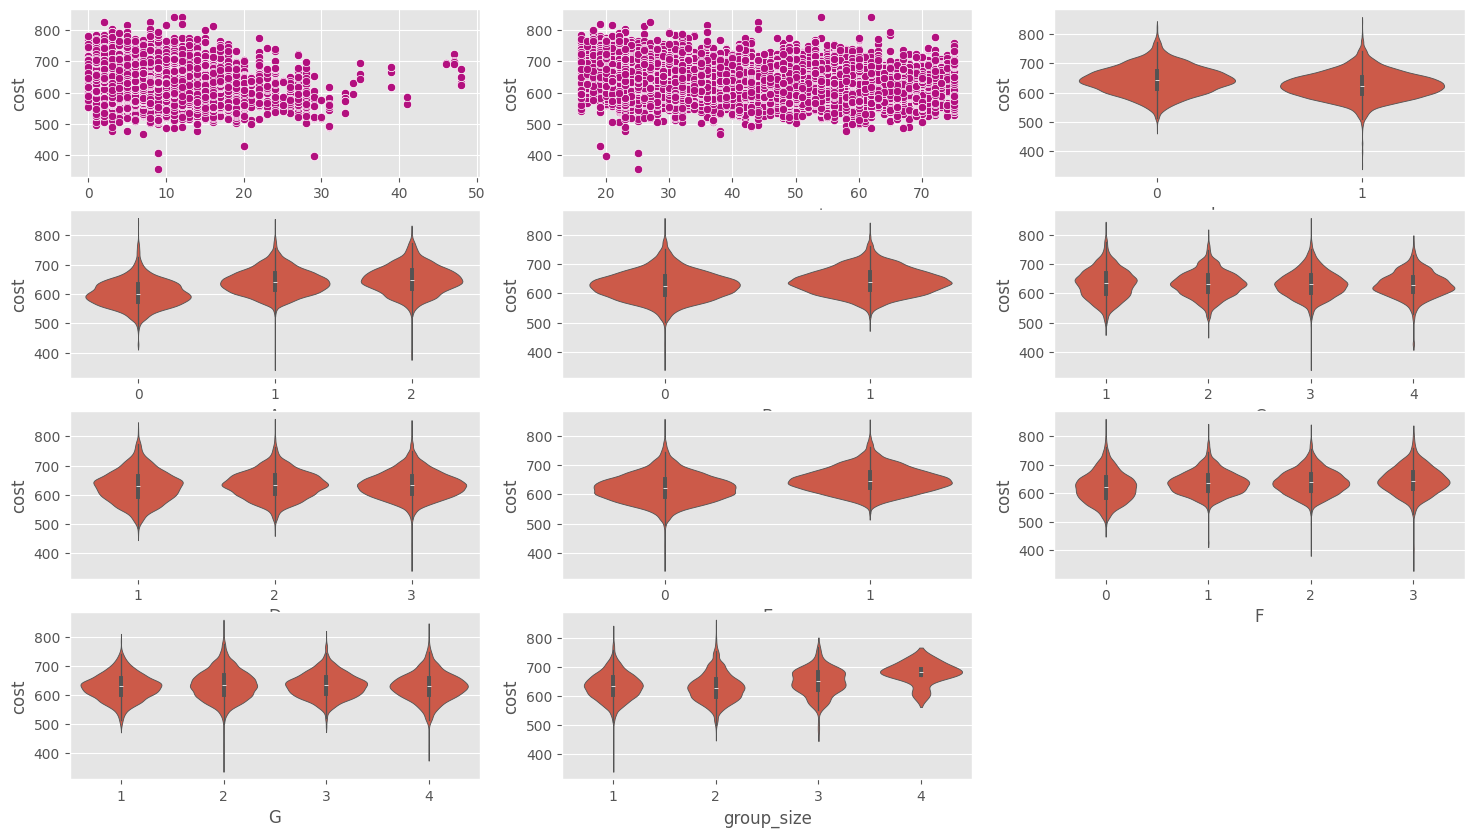

In [23]:
variables=['car_age','age_youngest','homeowner','A','B','C','D','E','F','G','group_size']

plt.figure(figsize=(18,10))
for i,var in enumerate(variables):
    plt.subplot(4,3,i+1)
    if var in ['A','B','C','D','E','F','G','homeowner','group_size']:
        sns.violinplot(x=var,y='cost',data=Datos)
    else:
        sns.scatterplot(x=var,y='cost',data=Datos,color="#B3107F")

## 📌 Introducción a la modelación:

Para preparar los datos de cara al ajuste de modelos predictivos, se realizó una transformación de las variables categóricas mediante codificación one-hot (dummies). En particular, se seleccionaron variables cualitativas relevantes como las coberturas (`A` a `G`), condiciones del cliente (`homeowner`, `married_couple`), características del grupo (`group_size`), historial (`C_previous`, `risk_factor`) y valor del vehículo (`car_value`). Utilizando `pd.get_dummies` con la opción `drop_first=True`, se evitó la colinealidad perfecta entre variables, facilitando la posterior interpretación de los coeficientes en modelos lineales y asegurando la compatibilidad con algoritmos que requieren variables numéricas. Este preprocesamiento permitió construir una matriz de diseño adecuada para el modelado supervisado del costo de la póliza.

In [24]:
Datos2 = Datos.copy()
variables2=['homeowner','A','B','C','D','E','F','G','group_size','car_value','C_previous','married_couple','risk_factor']
for var in variables2:
    Datos2=pd.get_dummies(Datos2,columns=[var],prefix=var,prefix_sep='_',drop_first=True, dtype=int)

In [25]:
Datos2.head(10)

,state,car_age,age_oldest,age_youngest,duration_previous,cost,homeowner_1,A_1,A_2,B_1,...,car_value_i,C_previous_1,C_previous_2,C_previous_3,C_previous_4,married_couple_1,risk_factor_1,risk_factor_2,risk_factor_3,risk_factor_4
0,OK,9,24,24,9.0,543,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,OK,9,24,24,9.0,611,0,0,1,1,...,0,0,0,1,0,0,0,0,0,0
2,PA,7,74,74,15.0,691,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,PA,7,74,74,15.0,695,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
4,AR,4,26,26,1.0,628,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
5,AR,4,26,26,1.0,625,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
6,AR,4,26,26,1.0,628,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
7,OK,13,22,22,0.0,596,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8,OK,13,22,22,0.0,711,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
9,OK,13,22,22,0.0,722,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0


In [26]:
X_train = Datos2.drop(columns = ['cost','state'])
y_train = Datos2['cost']

In [27]:
mlr = MultipleLinearRegression(method='ols')
mlr.fit(X_train, y_train)
mlr.summary()


Multiple Linear Regression Results
Method: OLS
Target Variable: cost

Feature Names:
  1. car_age
  2. age_oldest
  3. age_youngest
  4. duration_previous
  5. homeowner_1
  6. A_1
  7. A_2
  8. B_1
  9. C_2
  10. C_3
  11. C_4
  12. D_2
  13. D_3
  14. E_1
  15. F_1
  16. F_2
  17. F_3
  18. G_2
  19. G_3
  20. G_4
  21. group_size_2
  22. group_size_3
  23. group_size_4
  24. car_value_b
  25. car_value_c
  26. car_value_d
  27. car_value_e
  28. car_value_f
  29. car_value_g
  30. car_value_h
  31. car_value_i
  32. C_previous_1
  33. C_previous_2
  34. C_previous_3
  35. C_previous_4
  36. married_couple_1
  37. risk_factor_1
  38. risk_factor_2
  39. risk_factor_3
  40. risk_factor_4

Model Summary:
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.336
Method:

In [35]:
results = mlr.model.fit()

In [36]:
summary_df = pd.DataFrame({
    'feature': results.params.index,
    'coef': results.params.values,
    'std_err': results.bse.values,
    't': results.tvalues.values,
    'pval': results.pvalues.values,
    '[0.025': results.conf_int()[0].values,
    '0.975]': results.conf_int()[1].values
})

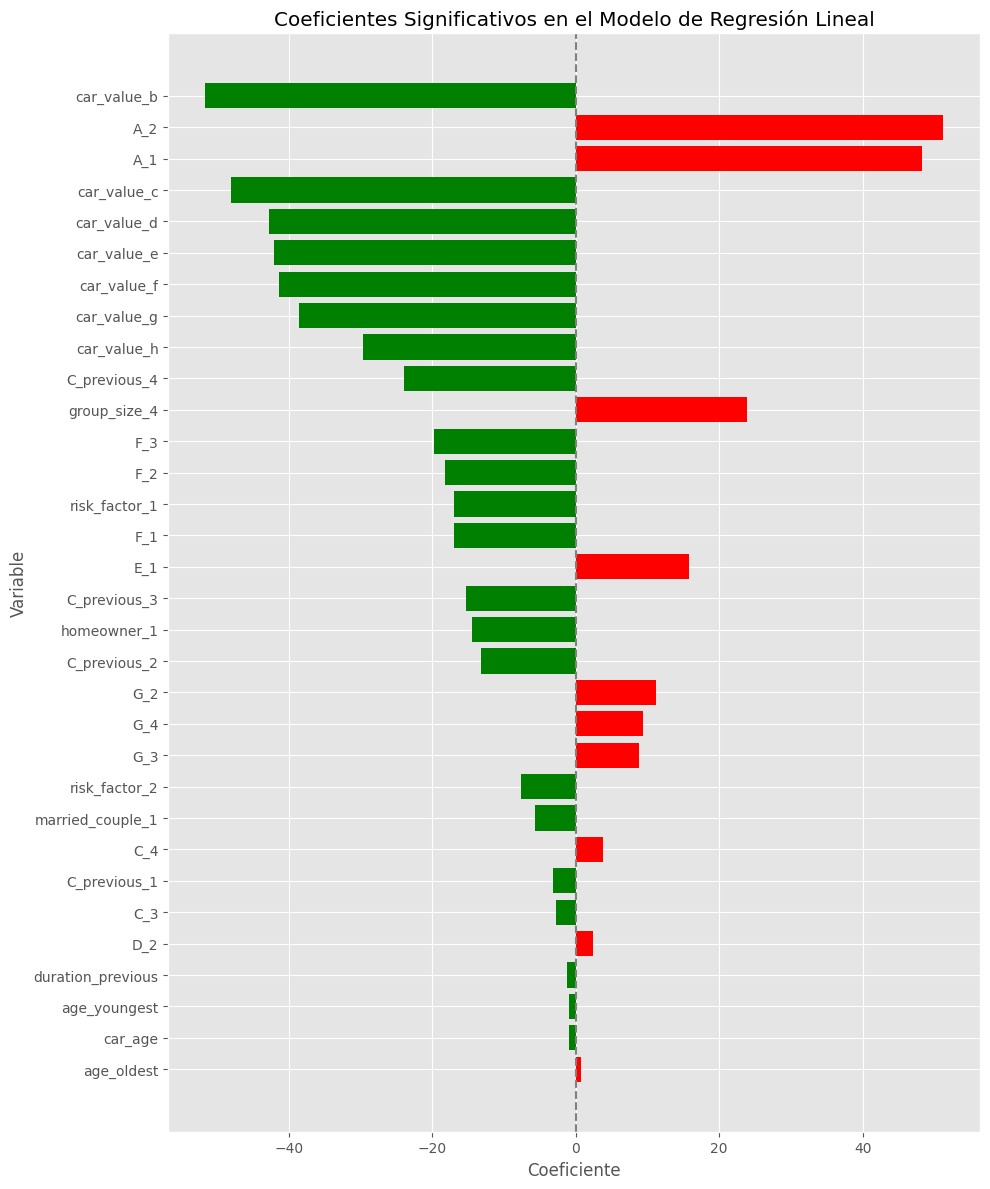

In [38]:
# DataFrame con coeficientes y p-valores (debes tenerlo cargado como 'df' previamente)
df_sig = summary_df[summary_df['pval'] < 0.05].sort_values(by='coef', key=abs, ascending=False)
df_sig = df_sig.query("feature != 'const'")

# Colores por signo
colors = df_sig['coef'].apply(lambda x: 'green' if x < 0 else 'red')

# Gráfico
plt.figure(figsize=(10, 12))
plt.barh(df_sig['feature'], df_sig['coef'], color=colors)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Coeficientes Significativos en el Modelo de Regresión Lineal')
plt.xlabel('Coeficiente')
plt.ylabel('Variable')
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

## 📌 Resumen del Modelo

- **R² = 0.338**: El modelo explica aproximadamente el **34% de la variabilidad** en el costo de la póliza.
- **Significancia global (F-test p < 0.001)**: El conjunto de variables incluidas es estadísticamente significativo.
- **Número de observaciones**: 15,483 pólizas analizadas.

---

## 🔍 Variables que AUMENTAN el Costo (coeficientes positivos y significativos)

| Variable        | Interpretación |
|----------------|----------------|
| `A_1`, `A_2`    | Mayor cobertura de colisión implica mayor costo. |
| `E_1`           | Incluir reembolso de alquiler eleva el costo. |
| `G_2`, `G_3`, `G_4` | Cobertura médica mayor está asociada a costos más altos. |
| `group_size_4`  | Grupos grandes tienden a tener pólizas más costosas. |
| `age_oldest`    | A mayor edad del miembro más viejo del grupo, mayor costo. |

---

## ✅ Variables que REDUCEN el Costo (coeficientes negativos y significativos)

| Variable           | Interpretación |
|--------------------|----------------|
| `car_age`          | Autos más antiguos suelen tener pólizas más baratas. |
| `homeowner_1`      | Ser propietario de vivienda está asociado a menor costo. |
| `F_1`, `F_2`, `F_3` | Cobertura exhaustiva en niveles altos reduce el costo, posiblemente por interacción con otras coberturas. |
| `risk_factor_1`, `risk_factor_2` | Menor nivel de riesgo percibido implica menor costo. |
| `car_value_*`      | Vehículos de menor valor tienden a tener costos más bajos. |
| `duration_previous`| Clientes con más años cubiertos previamente pagan menos. |
| `C_previous_1–4`   | Haber tenido cobertura previa, especialmente más alta, reduce el costo actual. |
| `married_couple_1` | Grupos con pareja casada presentan menores costos promedio. |

---

## ⚠️ Variables con Efecto No Significativo (p > 0.05)

- `B_1`
- `group_size_2`
- `group_size_3`
- `risk_factor_3`
- `risk_factor_4`
- `car_value_i`

Estas variables podrían considerarse prescindibles en modelos simplificados, dado su bajo aporte explicativo.

---

## 🧠 Conclusión General

El modelo identifica varias variables con efectos claros sobre el costo de la póliza. Entre los factores clave están:

- Antigüedad del vehículo (`car_age`)
- Tipo y nivel de cobertura (`A`, `E`, `F`, `G`)
- Perfil del cliente (`risk_factor`, `homeowner`, `married_couple`)
- Historial del cliente (`duration_previous`, `C_previous`)
- Valor del vehículo (`car_value_*`)

Aunque el R² sugiere margen de mejora, el modelo ya ofrece información útil para orientar estrategias de **tarifación**, **segmentación de clientes** y **diseño de productos aseguradores**.

In [39]:
X_train2 = Datos2[['A_1','A_2']]
mlr2 = MultipleLinearRegression(method='ols')
mlr2.fit(X_train2, y_train)

In [40]:
mlr2.summary()


Multiple Linear Regression Results
Method: OLS
Target Variable: cost

Feature Names:
  1. A_1
  2. A_2

Model Summary:
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.138
Method:                 Least Squares   F-statistic:                     1240.
Date:                Thu, 05 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:44:37   Log-Likelihood:                -80541.
No. Observations:               15483   AIC:                         1.611e+05
Df Residuals:                   15480   BIC:                         1.611e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      

In [41]:
X_train3 = Datos2[['car_age']]
mlr3 = MultipleLinearRegression(method='ols')
mlr3.fit(X_train3, y_train)

In [42]:
mlr3.summary()


Multiple Linear Regression Results
Method: OLS
Target Variable: cost

Feature Names:
  1. car_age

Model Summary:
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.065
Model:                            OLS   Adj. R-squared:                  0.065
Method:                 Least Squares   F-statistic:                     1081.
Date:                Thu, 05 Jun 2025   Prob (F-statistic):          3.59e-229
Time:                        20:44:37   Log-Likelihood:                -81169.
No. Observations:               15483   AIC:                         1.623e+05
Df Residuals:                   15481   BIC:                         1.624e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|

In [43]:
mlr3.results.mse_resid

np.float64(2094.694619131332)

In [44]:
import statsmodels.api as sm

In [45]:
np.linalg.inv(sm.add_constant(X_train3).values.T @ sm.add_constant(X_train3).values)

array([[ 1.92553546e-04, -1.58966162e-05],
       [-1.58966162e-05,  1.97475315e-06]])

In [46]:
np.sqrt(1.92553546e-04 * 2094.694619131332)

np.float64(0.6350912349425533)

In [47]:
Datos.groupby('A')['cost'].mean().reset_index()

C:\Users\legion\AppData\Local\Temp\ipykernel_28376\152501647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Datos.groupby('A')['cost'].mean().reset_index()


,A,cost
0,0,602.437397
1,1,642.373250
2,2,649.820021


In [48]:
# Get model summary
mlr.summary()


Multiple Linear Regression Results
Method: OLS
Target Variable: cost

Feature Names:
  1. car_age
  2. age_oldest
  3. age_youngest
  4. duration_previous
  5. homeowner_1
  6. A_1
  7. A_2
  8. B_1
  9. C_2
  10. C_3
  11. C_4
  12. D_2
  13. D_3
  14. E_1
  15. F_1
  16. F_2
  17. F_3
  18. G_2
  19. G_3
  20. G_4
  21. group_size_2
  22. group_size_3
  23. group_size_4
  24. car_value_b
  25. car_value_c
  26. car_value_d
  27. car_value_e
  28. car_value_f
  29. car_value_g
  30. car_value_h
  31. car_value_i
  32. C_previous_1
  33. C_previous_2
  34. C_previous_3
  35. C_previous_4
  36. married_couple_1
  37. risk_factor_1
  38. risk_factor_2
  39. risk_factor_3
  40. risk_factor_4

Model Summary:
----------------------------------------
                            OLS Regression Results                            
Dep. Variable:                   cost   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.336
Method:

Sampling 5000 records from 15483 for faster computation...
Running statistical tests...
- Computing Breusch-Pagan test...
- Computing Durbin-Watson test...
- Computing Shapiro-Wilk test...

Generating diagnostic plots...
Downsampling from 5000 to 1000 points for plotting...
Generating residuals plot...
Generating Q-Q plot...
Generating leverage plot...
Generating Cook's distance plot...


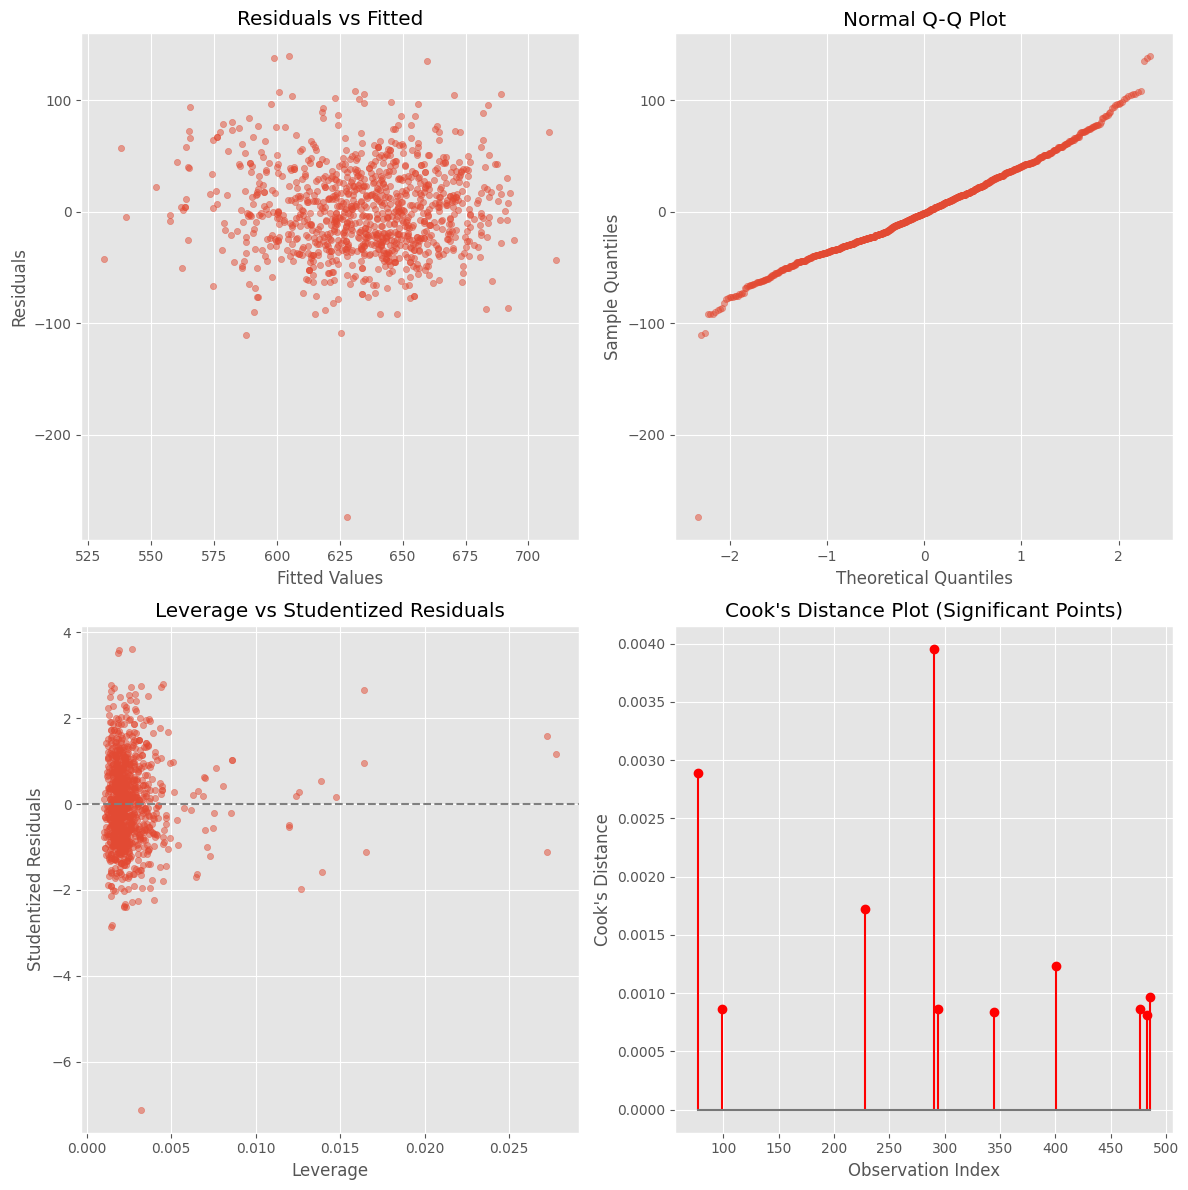

In [49]:
# Validate assumptions
diagnostics = mlr.validate_assumptions(X_train, y_train, plot=True,
                                       plots=['residuals', 'qq', 'leverage', 'cooks'])

In [50]:
diagnostics.__dict__

{'breusch_pagan_stat': 228.90924379320776,
 'breusch_pagan_pvalue': 2.5112013312147094e-28,
 'durbin_watson_stat': 2.013632257511746,
 'durbin_watson_pvalue': 0.0440481571055249,
 'shapiro_stat': 0.9870181106209632,
 'shapiro_pvalue': 4.734318400205819e-21}